#Importing Data using the News API

We will learn how to import real-world data using the [News API](https://newsapi.org/), a great resource for gathering data in news articles using code.

In [1]:
# As usual, begin by installing and importing the necessary packages...
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

After Registering for an API Key on [News API](https://newsapi.org/), retrieve your API Key and set it as a variable in Colab.

In [2]:
# Set your API Key
api_key = "6a41b7bba3224016be419171cfab7f34" # change this to your API Key

Then, perform a GET request. To do so, you'll need the following command:

`response = requests.get(url, headers=headers, params=params)`

where:

* `url` is the API Endpoint URL you wish to download data from
* `headers` is a dictionary containing your API Key
* `params` is a dictionary containing parameters to select which data you want to import.

In [3]:
# Point to the API Endpoint URL you wish to download data from
url = "https://newsapi.org/v2/everything" # e.g.: try "https://newsapi.org/v2/top-headlines"

# Pass your API Key as part of the 'headers' of the GET request (for authentication)
headers = {
    "X-Api-Key": api_key
}

# Define 'parameters' for the GET request (to limit retrieved data)
params = {
    "q": "tesla",
    "from": "2026-03-24",
    "sortBy": "publishedAt",
    "language": "en",
    "pageSize": 100
}

In [4]:
# Retrieve data from multiple days
all_articles = []

dates = pd.date_range(start="2026-03-24", end="2026-04-23")

for d in dates:
    params = {
        "q": "tesla",
        "from": str(d.date()),
        "to": str(d.date()),
        "language": "en",
        "pageSize": 100
    }

    response = requests.get(url, headers=headers, params=params)
    data = response.json()

    if "articles" in data:
        all_articles.extend(data["articles"])

df = pd.DataFrame(all_articles)

Then, inspect the data, and convert to a pandas dataframe for ease of handling.

In [5]:
# Data cleaning
# Time format
df["publishedAt"] = pd.to_datetime(df["publishedAt"])

# Extract the source name
df["source"] = df["source"].apply(lambda x: x["name"] if isinstance(x, dict) else None)

# Remove duplicates
df = df.drop_duplicates(subset="title")

# Remove na
df = df.dropna(subset=["title"])

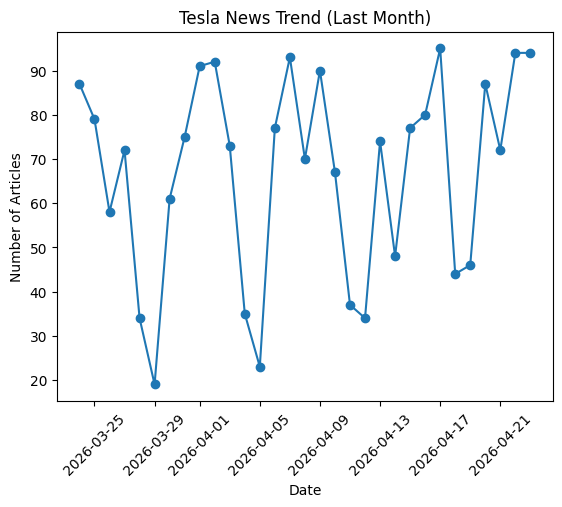

In [6]:
# News Trends
daily_count = df.groupby(df["publishedAt"].dt.date).size()

plt.figure()
daily_count.plot(marker='o')
plt.title("Tesla News Trend (Last Month)")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

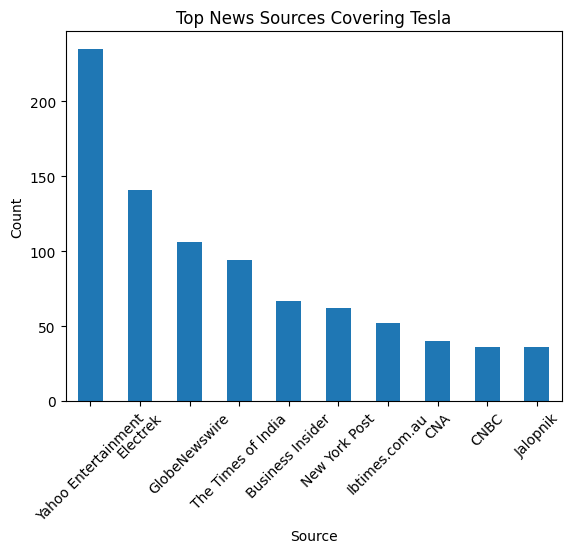

In [7]:
# Analysis of News Sources
top_sources = df["source"].value_counts().head(10)

plt.figure()
top_sources.plot(kind='bar')
plt.title("Top News Sources Covering Tesla")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

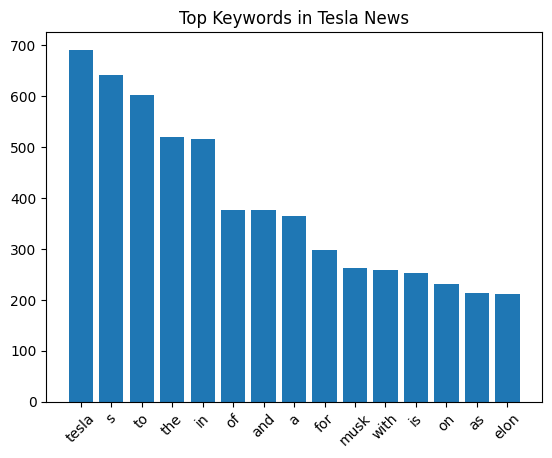

In [8]:
# Keyword Analysis
text = " ".join(df["title"].dropna())
words = re.findall(r'\b\w+\b', text.lower())

common_words = Counter(words).most_common(15)

words_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

plt.figure()
plt.bar(words_df["Word"], words_df["Frequency"])
plt.xticks(rotation=45)
plt.title("Top Keywords in Tesla News")
plt.show()

In [14]:
# Over the 30-day period from late March to late April 2026, Tesla generated substantial and consistent media attention,
# with daily article counts ranging from roughly 19 to 95. The volume trend reveals a volatile,
# wave-like pattern — sharp drops (notably around March 28–29 and April 4–5) followed by rapid recoveries
# — suggesting that coverage is highly reactive to discrete news events rather than sustained by a steady narrative.
# Coverage intensified notably in mid-to-late April, with multiple days hitting the 90+ article range, hinting at a period of heightened public or investor interest.
# In terms of sourcing, Yahoo Entertainment dominated with approximately 235 articles, followed by the EV-focused outlet Electrek (~142) and GlobeNewswire (~107),
# indicating that Tesla's story was driven by both mainstream entertainment-adjacent media and specialized automotive/tech press.
# The keyword frequency analysis confirms that beyond the expected term "tesla" the name "musk" and "elon" both appear prominently in the top 15
# — underscoring how inseparable Elon Musk's personal brand remains from Tesla's media identity. ")